In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv("13-car_evaluation.csv")

In [3]:
df.head()

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [4]:
df.columns

Index(['vhigh', 'vhigh.1', '2', '2.1', 'small', 'low', 'unacc'], dtype='object')

In [5]:
df.shape

(1727, 7)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   vhigh    1727 non-null   object
 1   vhigh.1  1727 non-null   object
 2   2        1727 non-null   object
 3   2.1      1727 non-null   object
 4   small    1727 non-null   object
 5   low      1727 non-null   object
 6   unacc    1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [7]:
col_names=["buying","maint","doors","persons","lug_boot","safety","class"]

In [8]:
df.columns=col_names

In [9]:
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [10]:
for col in df.columns:
    print(df[col].value_counts())

buying
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
maint
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
doors
3        432
4        432
5more    432
2        431
Name: count, dtype: int64
persons
4       576
more    576
2       575
Name: count, dtype: int64
lug_boot
med      576
big      576
small    575
Name: count, dtype: int64
safety
med     576
high    576
low     575
Name: count, dtype: int64
class
unacc    1209
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [11]:
df.isnull().sum()

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

In [12]:
df["doors"].unique()

array(['2', '3', '4', '5more'], dtype=object)

In [13]:
df["doors"]=df["doors"].replace("5more",5)

In [14]:
df["doors"].unique()

array(['2', '3', '4', 5], dtype=object)

In [15]:
df["doors"]=df["doors"].astype(int)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1727 non-null   object
 1   maint     1727 non-null   object
 2   doors     1727 non-null   int64 
 3   persons   1727 non-null   object
 4   lug_boot  1727 non-null   object
 5   safety    1727 non-null   object
 6   class     1727 non-null   object
dtypes: int64(1), object(6)
memory usage: 94.6+ KB


In [17]:
df["persons"].unique()


array(['2', '4', 'more'], dtype=object)

In [18]:
df["persons"]=df["persons"].replace("more",5)

In [19]:
df["persons"].value_counts()

persons
4    576
5    576
2    575
Name: count, dtype: int64

In [20]:
df["persons"]=df["persons"].astype(int)

In [21]:
df["persons"].unique()

array([2, 4, 5])

In [22]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1727 non-null   object
 1   maint     1727 non-null   object
 2   doors     1727 non-null   int64 
 3   persons   1727 non-null   int64 
 4   lug_boot  1727 non-null   object
 5   safety    1727 non-null   object
 6   class     1727 non-null   object
dtypes: int64(2), object(5)
memory usage: 94.6+ KB


<Axes: xlabel='buying', ylabel='maint'>

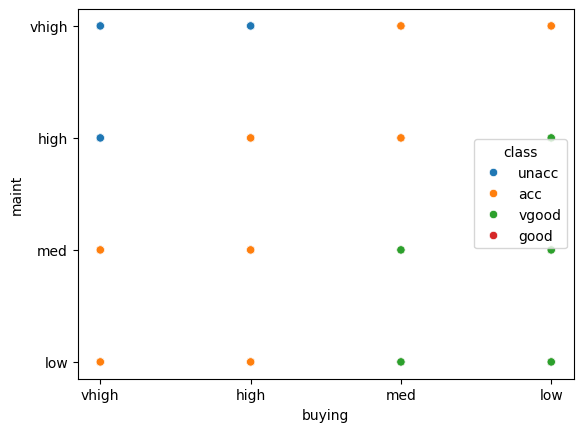

In [23]:
sns.scatterplot(x=df["buying"],y=df["maint"],hue=df["class"])

<Axes: xlabel='lug_boot', ylabel='safety'>

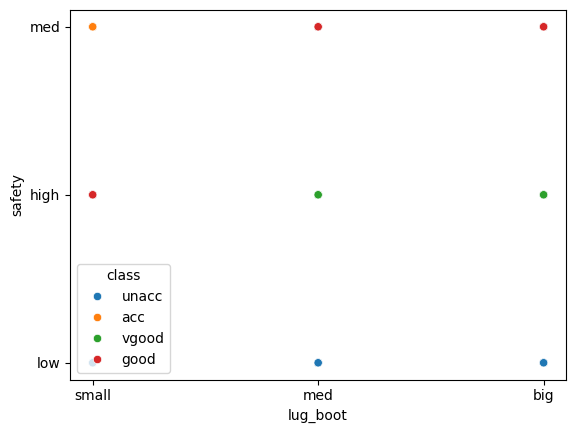

In [24]:
sns.scatterplot(x=df["lug_boot"],y=df["safety"],hue=df["class"])

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1727 non-null   object
 1   maint     1727 non-null   object
 2   doors     1727 non-null   int64 
 3   persons   1727 non-null   int64 
 4   lug_boot  1727 non-null   object
 5   safety    1727 non-null   object
 6   class     1727 non-null   object
dtypes: int64(2), object(5)
memory usage: 94.6+ KB


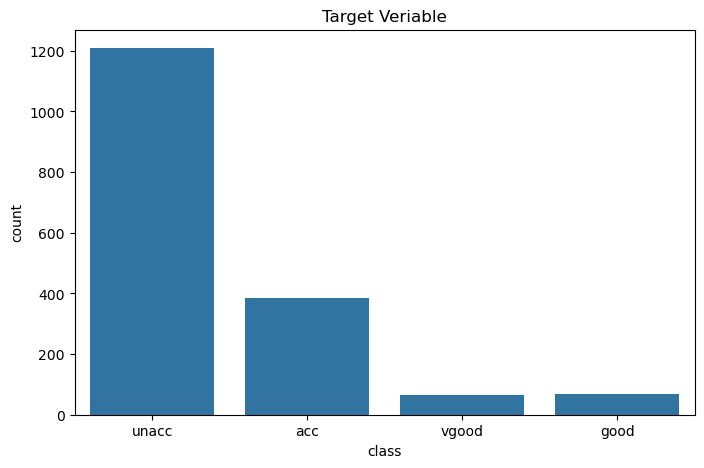

In [26]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='class')
plt.title('Target Veriable')
plt.show()

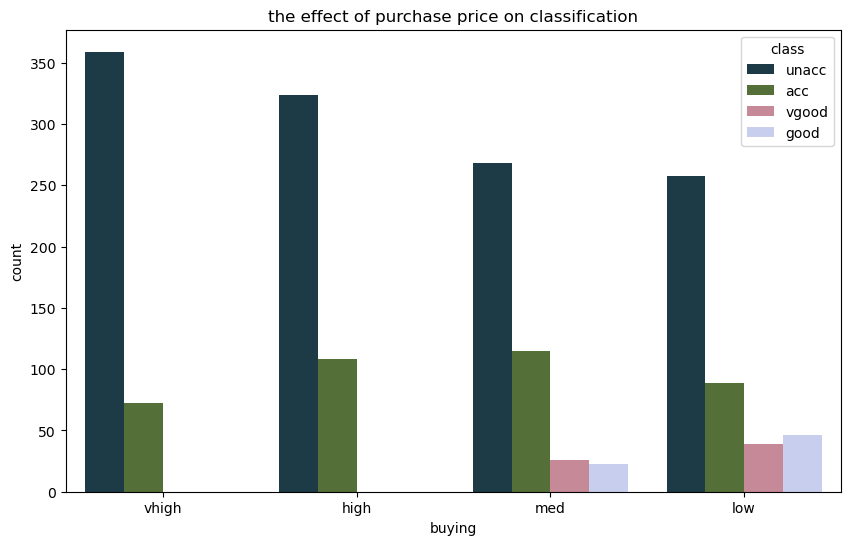

In [27]:
plt.figure(figsize=(10, 6))
# buying (alım fiyatı) özelliğini incele
sns.countplot(data=df, x='buying', hue='class', palette='cubehelix')
plt.title('the effect of purchase price on classification')
plt.show()

In [28]:
X=df.drop("class",axis=1)
y=df["class"]

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=15)

In [31]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [32]:
categorical_cols=["buying","maint","lug_boot","safety"]
numeric_col=["doors","persons"]
ordinal_encoder=OrdinalEncoder(categories=[
    ["low","med","high","vhigh"],
    ["low","med","high","vhigh",],
    ["small","med","big"],
    ["low","med","high"]
])
preprocessor=ColumnTransformer(transformers=[
    ("transformation_name",ordinal_encoder,categorical_cols)
    ##  örnek ("transformation_name",label_encoder,categorical_cols), gibi diğer kolonlar içinde yapılabilir
    
],remainder="passthrough")
X_train_transformed=preprocessor.fit_transform(X_train)
X_test_transformed=preprocessor.transform(X_test)

In [33]:
##for col in categorical_cols:
  ##  print(df[col].value_counts())

In [34]:
pd.DataFrame(X_train_transformed)[5].unique()

array([2., 4., 5.])

In [35]:
## model start

In [36]:
from sklearn.tree import DecisionTreeClassifier

In [37]:
tree_model=DecisionTreeClassifier(criterion="gini",max_depth=3,random_state=0)

In [38]:
tree_model.fit(X_train_transformed,y_train)

DecisionTreeClassifier(max_depth=3, random_state=0)

In [39]:
y_pred=tree_model.predict(X_test_transformed)

In [40]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [41]:
print("accuarcy score:",accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

accuarcy score: 0.7893518518518519
[[ 44   0  49   0]
 [ 19   0   0   0]
 [  8   0 297   0]
 [ 15   0   0   0]]
              precision    recall  f1-score   support

         acc       0.51      0.47      0.49        93
        good       0.00      0.00      0.00        19
       unacc       0.86      0.97      0.91       305
       vgood       0.00      0.00      0.00        15

    accuracy                           0.79       432
   macro avg       0.34      0.36      0.35       432
weighted avg       0.72      0.79      0.75       432



C:\Users\ahmet\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ahmet\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ahmet\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[Text(0.3333333333333333, 0.875, 'safety <= 0.5\ngini = 0.459\nsamples = 1295\nvalue = [291, 50, 904, 50]'),
 Text(0.16666666666666666, 0.625, 'gini = 0.0\nsamples = 436\nvalue = [0, 0, 436, 0]'),
 Text(0.25, 0.75, 'True  '),
 Text(0.5, 0.625, 'persons <= 3.0\ngini = 0.582\nsamples = 859\nvalue = [291.0, 50.0, 468.0, 50.0]'),
 Text(0.41666666666666663, 0.75, '  False'),
 Text(0.3333333333333333, 0.375, 'gini = 0.0\nsamples = 281\nvalue = [0, 0, 281, 0]'),
 Text(0.6666666666666666, 0.375, 'buying <= 1.5\ngini = 0.627\nsamples = 578\nvalue = [291.0, 50.0, 187.0, 50.0]'),
 Text(0.5, 0.125, 'gini = 0.639\nsamples = 298\nvalue = [160, 50, 38, 50]'),
 Text(0.8333333333333334, 0.125, 'gini = 0.498\nsamples = 280\nvalue = [131, 0, 149, 0]')]

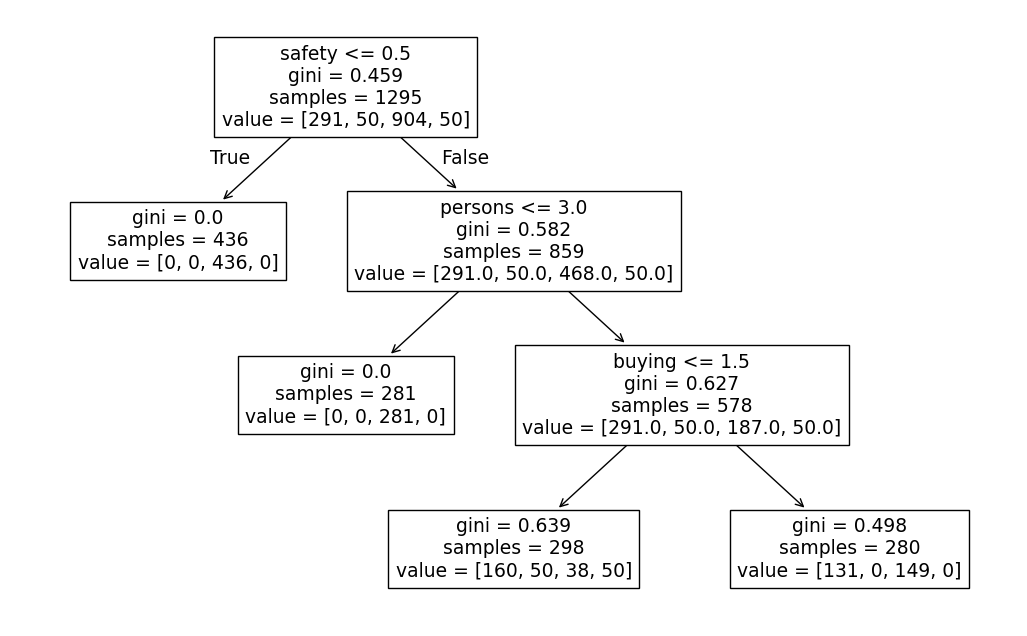

In [44]:
plt.figure(figsize=(13,8))
from sklearn import tree
column_names=categorical_cols + numeric_col
tree.plot_tree(tree_model.fit(X_train_transformed,y_train),feature_names=column_names)

In [45]:
param = {
    "criterion" : ["gini", "entropy", "log_loss"],
    "splitter" : ["best", "random"],
    "max_depth" : [1,2,3,4,5,15,None],
    "max_features" : ["sqrt", "log2", None]
}

In [46]:
from sklearn.model_selection import GridSearchCV


In [56]:
grid= GridSearchCV(estimator = DecisionTreeClassifier(), param_grid=param, cv=5,scoring="accuracy")


In [66]:
import warnings
warnings.filterwarnings("ignore")
grid.fit(X_train_transformed, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [1, 2, 3, 4, 5, 15, None],
                         'max_features': ['sqrt', 'log2', None],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

In [67]:
grid.best_score_

np.float64(0.972972972972973)

In [60]:
tree_model_new.best_params_

{'criterion': 'log_loss',
 'max_depth': 15,
 'max_features': None,
 'splitter': 'best'}

In [68]:
y_pred=grid.predict(X_test_transformed)

In [70]:
grid = DecisionTreeClassifier(criterion="entropy",max_depth=None, max_features=None, splitter="best")


In [72]:
tree_model_new = DecisionTreeClassifier(criterion="entropy",max_depth=None, max_features=None, splitter="best")


In [73]:
tree_model_new.fit(X_train_transformed, y_train)
y_pred = tree_model_new.predict(X_test_transformed)
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


0.9791666666666666
[[ 91   0   1   1]
 [  3  16   0   0]
 [  4   0 301   0]
 [  0   0   0  15]]
              precision    recall  f1-score   support

         acc       0.93      0.98      0.95        93
        good       1.00      0.84      0.91        19
       unacc       1.00      0.99      0.99       305
       vgood       0.94      1.00      0.97        15

    accuracy                           0.98       432
   macro avg       0.97      0.95      0.96       432
weighted avg       0.98      0.98      0.98       432



[Text(0.5971283783783784, 0.9615384615384616, 'safety <= 0.5\nentropy = 1.209\nsamples = 1295\nvalue = [291, 50, 904, 50]'),
 Text(0.5836148648648649, 0.8846153846153846, 'entropy = 0.0\nsamples = 436\nvalue = [0, 0, 436, 0]'),
 Text(0.5903716216216217, 0.9230769230769231, 'True  '),
 Text(0.6106418918918919, 0.8846153846153846, 'persons <= 3.0\nentropy = 1.484\nsamples = 859\nvalue = [291.0, 50.0, 468.0, 50.0]'),
 Text(0.6038851351351351, 0.9230769230769231, '  False'),
 Text(0.5971283783783784, 0.8076923076923077, 'entropy = 0.0\nsamples = 281\nvalue = [0, 0, 281, 0]'),
 Text(0.6241554054054054, 0.8076923076923077, 'buying <= 1.5\nentropy = 1.636\nsamples = 578\nvalue = [291.0, 50.0, 187.0, 50.0]'),
 Text(0.3902027027027027, 0.7307692307692307, 'maint <= 1.5\nentropy = 1.725\nsamples = 298\nvalue = [160, 50, 38, 50]'),
 Text(0.19932432432432431, 0.6538461538461539, 'safety <= 1.5\nentropy = 1.797\nsamples = 148\nvalue = [49, 50, 8, 41]'),
 Text(0.08108108108108109, 0.5769230769230769

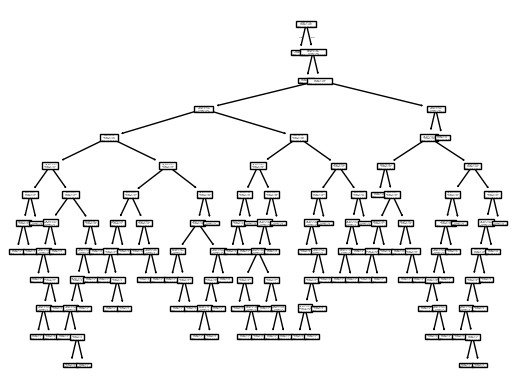

In [74]:
tree.plot_tree(tree_model_new.fit(X_train_transformed, y_train),feature_names=column_names)
